# Exploratory Data Analysis of the Disaster Tweets Dataset
By: Mishell Guano

This notebook performs an exploratory data analysis (EDA) of the Disaster Tweets dataset. 
The objective is to understand the structure, quality, and linguistic characteristics of the tweets in order to identify patterns that may help in disaster-related tweet classification.

The analysis includes:

- Dataset structure and data quality inspection
- Duplicate and retweet detection
- Text length analysis
- Extraction of URLs, mentions, and hashtags
- Lexical analysis (n-grams)
- Hashtag analysis
- Class distribution analysis
- Sentiment analysis
- Feature engineering preparation for modeling

The insights obtained from this analysis will support feature engineering and model development for disaster tweet classification.

### Import Libraries

This section imports the required libraries for data manipulation, visualization, text processing, and dataset retrieval.

In [34]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

### Dataset Loading

The dataset is retrieved directly from Kaggle using the kagglehub library. 
Once downloaded, the CSV file is identified and loaded into a pandas DataFrame for further analysis.
This section inspects the structure of the dataset. Understanding the size of the dataset and the available columns is essential before performing any preprocessing or analysis.

## 1. Dataset Overview


In [60]:
path = kagglehub.dataset_download("vstepanenko/disaster-tweets")

files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [36]:
df.shape

(11370, 5)

### Data Types and Missing Values

Inspecting the data types of each column helps determine whether any type conversions are necessary. 
Missing value analysis is also important to identify fields that require cleaning or imputation.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [38]:
df.isnull().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

### Cardinality and Unique Values

Cardinality analysis measures the number of unique values in categorical variables such as users, locations, or keywords. 
This helps identify dominant categories and detect sparse or rare values that may affect modeling.

In social media datasets, high-cardinality variables such as users or locations can indicate a wide diversity of sources, while low-cardinality variables may reveal dominant contributors or repeated categories.

This analysis focuses on the number of unique values for key attributes such as locations, hashtags, and classification labels. Identifying these patterns helps detect dominant categories as well as rare values that may influence the dataset distribution.

In [55]:
print("Unique locations:", df["location"].nunique())
print("Unique labels:", df["target"].nunique())

Unique locations: 4458
Unique labels: 2


### Hashtag Analysis

Hashtags often describe the main topic of a tweet. 
Extracting and analyzing hashtag frequencies can reveal dominant disaster-related topics.

In [ ]:
df["hashtags"] = df["text"].apply(lambda x: re.findall(r"#\w+", x))

In [57]:
all_hashtags = [tag for tags in df["hashtags"] for tag in tags]

unique_hashtags = set(all_hashtags)

print("Unique hashtags:", len(unique_hashtags))

Unique hashtags: 1810


In [58]:
all_hashtags = [tag for tags in df["hashtags"] for tag in tags]

hashtag_counts = Counter(all_hashtags)

hashtag_counts.most_common(10)

[('#Iran', 25),
 ('#StormBrendan', 22),
 ('#China', 14),
 ('#earthquake', 12),
 ('#TaalVolcano', 12),
 ('#iHeartAwards', 11),
 ('#NeelumValley', 11),
 ('#Kashmir', 10),
 ('#PuertoRico', 9),
 ('#bushfires', 9)]

## 2. Text Quality and Cleaning

Before performing deeper linguistic analysis or building predictive models, it is important to evaluate the quality of the textual data. Social media datasets often contain duplicated messages, retweets, missing text entries, or structural elements such as URLs, mentions, and hashtags.

These elements can introduce noise or bias if they are not properly handled during preprocessing. For this reason, this section evaluates several aspects of text quality and structure.

The analysis includes:

- Detection of duplicated tweets
- Identification of retweets
- Detection of missing or empty text entries
- Tweet length analysis
- Extraction of URLs
- Extraction of user mentions
- Extraction of hashtags
- Extraction of emojis

Understanding these characteristics helps guide later preprocessing steps and feature engineering for natural language processing models.

### Duplicate Tweets

Duplicate tweets can introduce bias during analysis and model training. 
This step identifies duplicated tweets based on their text content.

In [61]:
duplicate_count = df.duplicated(subset="text").sum()
print("Number of duplicate tweets:", duplicate_count)

Number of duplicate tweets: 147


In [62]:
#delete duplicates
df = df.drop_duplicates(subset="text")

### Retweet Identification

Retweets represent reposted content from other users and may significantly increase the frequency of specific messages. Retweets are typically identified by the prefix "RT @" at the beginning of the tweet.

Detecting retweets allows us to measure how much content repetition exists in the dataset.

In [42]:
df["is_retweet"] = df["text"].str.startswith("RT @")
df["is_retweet"].value_counts()

is_retweet
False    11223
Name: count, dtype: int64

### Missing or Empty Text Entries

Some tweets may contain missing values or empty text fields. These entries provide no linguistic information and may affect text-based analysis.

This step checks for missing or empty text values.

In [63]:
missing_text = df["text"].isnull().sum()
print("Missing text entries:", missing_text)

Missing text entries: 0


In [64]:
empty_text = (df["text"].str.strip() == "").sum()
print("Empty text entries:", empty_text)

Empty text entries: 0


### Tweet Length Analysis

Analyzing tweet length helps understand how much textual information is available in each observation. Extremely short or extremely long tweets may represent noise or outliers.

Two metrics are used:

- Character length: number of characters in the tweet
- Token length: number of words in the tweet

In [43]:
df["char_length"] = df["text"].apply(len)
df["token_length"] = df["text"].apply(lambda x: len(x.split()))

The distribution of tweet token lengths shows that most tweets contain between 18 and 22 tokens, with a peak around 20 tokens. Very short tweets (less than 5 tokens) and longer tweets (more than 26 tokens) appear less frequently. This indicates that the dataset is composed mainly of medium-length tweets.

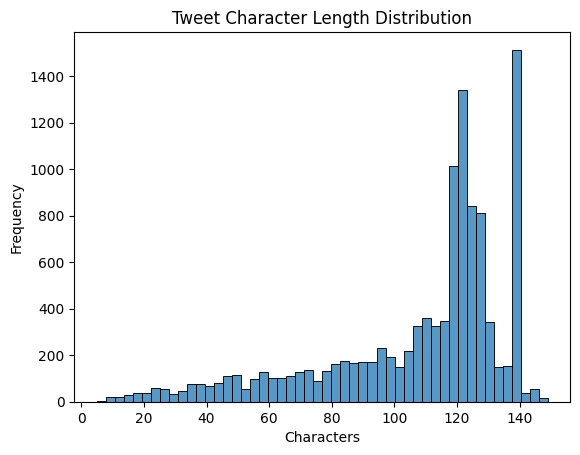

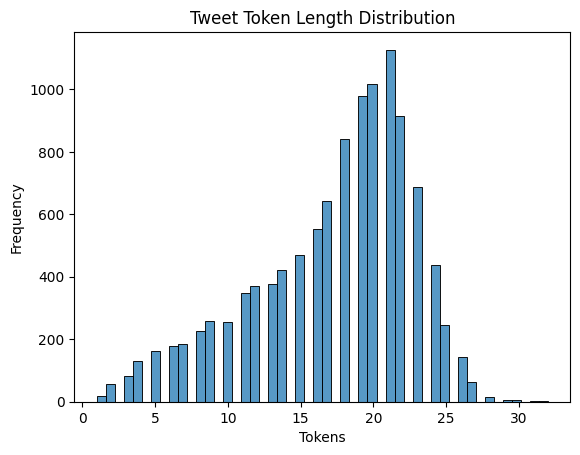

In [54]:
# Plot character and token length distributions
plt.figure()
sns.histplot(df["char_length"], bins=50)
plt.title("Tweet Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()
plt.figure()
sns.histplot(df["token_length"], bins=50)
plt.title("Tweet Token Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

### URL Extraction

Tweets frequently include URLs linking to external news articles, images, or additional information. URLs can provide useful features for classification tasks.

This step extracts URLs and counts their occurrences.

In [46]:
df["urls"] = df["text"].apply(lambda x: re.findall(r"http\S+", x))
df["url_count"] = df["urls"].apply(len)

df["url_count"].describe()

count    11223.000000
mean         0.508509
std          0.549374
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: url_count, dtype: float64

### Mention Extraction

Mentions represent references to other Twitter users using the "@" symbol. These mentions may indicate information sharing or communication between users.

This step extracts user mentions from the tweet text.

In [65]:
df["mentions"] = df["text"].apply(lambda x: re.findall(r"@\w+", x))
df["mention_count"] = df["mentions"].apply(len)

df["mention_count"].describe()

count    11223.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: mention_count, dtype: float64

### Hashtag Extraction

Hashtags are frequently used in tweets to categorize topics or highlight specific events. In disaster-related tweets, hashtags often reference specific incidents or locations.

This step extracts hashtags from the tweet text.

In [66]:
len(all_hashtags)

2579

### Emoji Extraction

Emojis can convey emotional tone or urgency in tweets. Although they are less structured than text, they may provide additional sentiment information.

This step detects emojis using a regular expression pattern that captures common Unicode emoji ranges.

In [71]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "]",
    flags=re.UNICODE
)

df["emojis"] = df["text"].apply(lambda x: emoji_pattern.findall(x))
df["emoji_count"] = df["emojis"].apply(len)

df["emoji_count"].describe()


count    11223.000000
mean         0.137486
std          0.831181
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         34.000000
Name: emoji_count, dtype: float64

### Section Summary

The dataset initially contained 147 duplicate tweets, which were removed, resulting in 11,223 unique tweets. No retweets were detected, indicating that the dataset consists mainly of original posts.

No missing or empty text entries were found, meaning all observations contain valid textual content.

Tweet length analysis shows that most tweets contain around 20 tokens and between 115 and 135 characters, suggesting that users tend to use most of the available character limit.

URLs appear occasionally, with an average of about 0.5 URLs per tweet, while mentions are not present in the dataset. A total of 2,579 hashtags were identified, indicating moderate hashtag usage. Emoji usage is relatively low overall, although some tweets contain multiple emojis.

Overall, the dataset contains medium-length tweets with limited structural elements, making it suitable for further linguistic analysis and feature engineering.

## 3. Lexical and Surface-Level Analysis

This section examines the lexical and structural characteristics of the tweets. 
Analyzing word usage patterns, hashtags, punctuation, and emoji usage helps identify linguistic signals that may distinguish disaster-related tweets from non-disaster tweets.

The analysis includes:

- Frequency analysis of unigrams, bigrams, and trigrams
- Hashtag frequency and co-occurrence analysis
- Comparison between stopwords and content words
- Punctuation and capitalization patterns
- Emoji usage and distribution by class

These features may provide useful signals for natural language processing models and help identify vocabulary associated with disaster events.

### Unigram Frequency Analysis

Unigrams represent single words in the text. 
Analyzing the most frequent unigrams helps identify commonly used vocabulary within the dataset and may reveal terms associated with disaster events.

In [50]:
vectorizer = CountVectorizer(stop_words="english", max_features=20)

X = vectorizer.fit_transform(df["text"])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

word_freq = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values(by="count", ascending=False)

word_freq

,word,count
4,https,5693
0,amp,603
6,just,575
8,like,540
12,people,534
2,don,287
11,new,272
15,time,251
7,know,240
5,iran,233


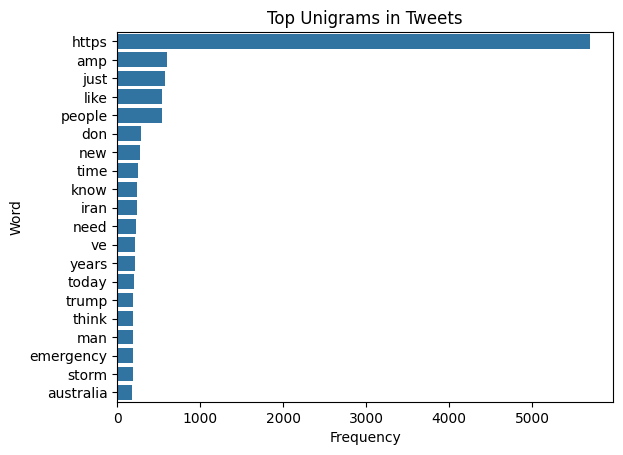

In [73]:
plt.figure()
sns.barplot(x="count", y="word", data=word_freq)

plt.title("Top Unigrams in Tweets")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Bigram Frequency Analysis

Bigrams represent pairs of consecutive words. 
They help capture short contextual patterns that may describe disaster-related events.

In [74]:
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(df["text"])

bigrams = bigram_vectorizer.get_feature_names_out()
counts = X_bigram.sum(axis=0).A1

bigram_freq = pd.DataFrame({
    "bigram": bigrams,
    "count": counts
}).sort_values(by="count", ascending=False)

bigram_freq

,bigram,count
15,taal volcano,89
2,climate change,52
19,years ago,48
16,th https,45
1,bush fires,42
4,emergency services,42
8,mass murder,40
0,body bags,39
10,puerto rico,39
12,severe thunderstorm,39


### Trigram Frequency Analysis

Trigrams represent sequences of three consecutive words. 
They provide more context than unigrams or bigrams and may highlight specific phrases used when describing disaster events.

In [75]:
trigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3,3),
    max_features=20
)

X_trigram = trigram_vectorizer.fit_transform(df["text"])

trigrams = trigram_vectorizer.get_feature_names_out()
counts = X_trigram.sum(axis=0).A1

trigram_freq = pd.DataFrame({
    "trigram": trigrams,
    "count": counts
}).sort_values(by="count", ascending=False)

trigram_freq

,trigram,count
12,severe thunderstorm warning,35
10,party gove heart,34
16,triumphant party gove,34
1,brace years upheaval,33
19,years upheaval triumphant,33
17,upheaval triumphant party,33
11,schools brace years,33
0,battle id need,23
14,taal volcano eruption,23
3,gove heart melissa,23


### Hashtag Frequency Analysis

Hashtags often summarize the main topic of a tweet and may indicate specific events or disaster-related discussions. 
Analyzing hashtag frequencies helps identify dominant themes within the dataset.

In [77]:
hashtag_counts = Counter(all_hashtags)

top_hashtags = pd.DataFrame(
    hashtag_counts.most_common(10),
    columns=["hashtag","count"]
)

top_hashtags

,hashtag,count
0,#Iran,25
1,#StormBrendan,22
2,#China,14
3,#earthquake,12
4,#TaalVolcano,12
5,#iHeartAwards,11
6,#NeelumValley,11
7,#Kashmir,10
8,#PuertoRico,9
9,#bushfires,9


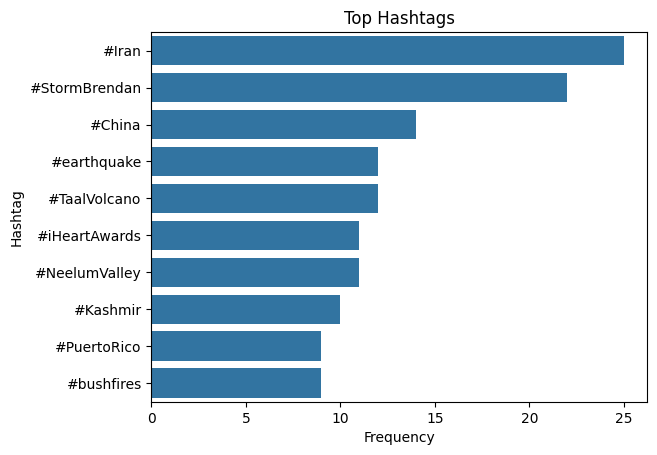

In [78]:
plt.figure()

sns.barplot(x="count", y="hashtag", data=top_hashtags)

plt.title("Top Hashtags")
plt.xlabel("Frequency")
plt.ylabel("Hashtag")

plt.show()

### Stopword vs Content Word Comparison

Stopwords are commonly used words such as "the", "is", and "and" that usually carry little semantic meaning. 
Removing stopwords often improves the quality of text analysis by focusing on meaningful content words.

This comparison illustrates the most frequent words when stopwords are not removed.

In [79]:
vectorizer_no_stop = CountVectorizer(max_features=20)

X = vectorizer_no_stop.fit_transform(df["text"])

words = vectorizer_no_stop.get_feature_names_out()
counts = X.sum(axis=0).A1

stopword_compare = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values(by="count", ascending=False)

stopword_compare

,word,count
13,the,7599
5,https,5693
3,co,5633
15,to,4297
10,of,3590
6,in,3374
0,and,3133
7,is,2300
4,for,1677
19,you,1608


In [82]:
vectorizer_with_stop = CountVectorizer(
    max_features=20,
    stop_words="english"
)

X_no_stop = vectorizer_with_stop.fit_transform(df["text"])

words_no_stop = vectorizer_with_stop.get_feature_names_out()
counts_no_stop = X_no_stop.sum(axis=0).A1

no_stopword_compare = pd.DataFrame({
    "word": words_no_stop,
    "count": counts_no_stop
}).sort_values(by="count", ascending=False)

no_stopword_compare

,word,count
4,https,5693
0,amp,603
6,just,575
8,like,540
12,people,534
2,don,287
11,new,272
15,time,251
7,know,240
5,iran,233


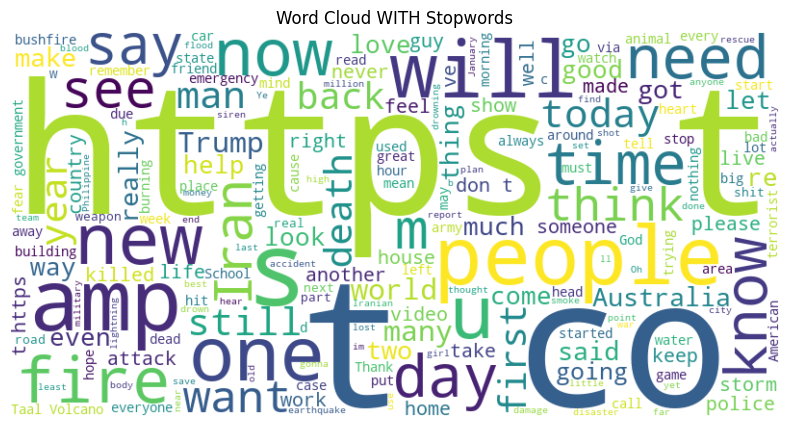

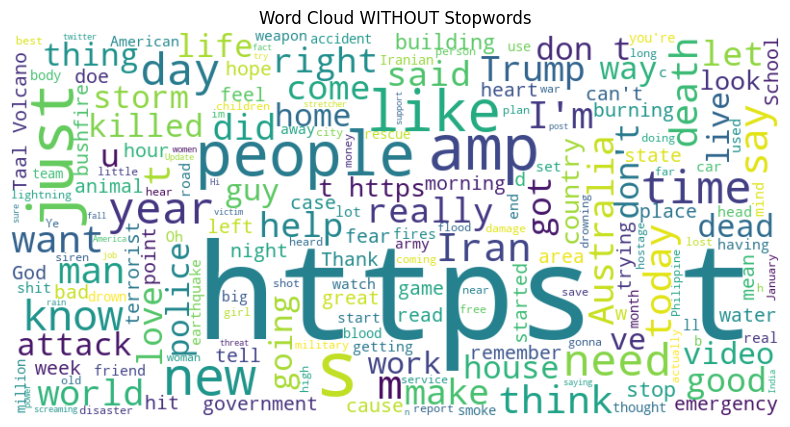

In [81]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# WordCloud con stopwords
text_with_stopwords = " ".join(df["text"])

wc_with = WordCloud(width=800, height=400, background_color="white").generate(text_with_stopwords)

plt.figure(figsize=(10,5))
plt.imshow(wc_with, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud WITH Stopwords")
plt.show()


# WordCloud sin stopwords
text_without_stopwords = " ".join(df["text"])

wc_without = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=ENGLISH_STOP_WORDS
).generate(text_without_stopwords)

plt.figure(figsize=(10,5))
plt.imshow(wc_without, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud WITHOUT Stopwords")
plt.show()

### Punctuation Patterns

Punctuation marks such as exclamation marks and question marks can indicate urgency, alarm, or uncertainty. 
Counting these patterns helps capture emotional intensity in tweets.

In [84]:
df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df[["exclamation_count","question_count"]].describe()

,exclamation_count,question_count
count,11223.000000,11223.000000
mean,0.125991,0.092400
std,0.600440,0.408559
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,25.000000,9.000000


### Capitalization Analysis

Tweets that contain a high proportion of uppercase characters may signal urgency or strong emotional reactions. 
This analysis computes the ratio of uppercase characters relative to the total text length.

In [85]:
def uppercase_ratio(text):
    uppercase_chars = sum(1 for c in text if c.isupper())
    return uppercase_chars / len(text) if len(text) > 0 else 0

df["uppercase_ratio"] = df["text"].apply(uppercase_ratio)

df["uppercase_ratio"].describe()

count    11223.000000
mean         0.074436
std          0.091871
min          0.000000
25%          0.031746
50%          0.053763
75%          0.085714
max          1.000000
Name: uppercase_ratio, dtype: float64

### Emoji Usage by Class

Emojis can convey emotional tone and may appear more frequently in certain types of tweets. 
This step compares the number of emojis across the disaster and non-disaster classes.

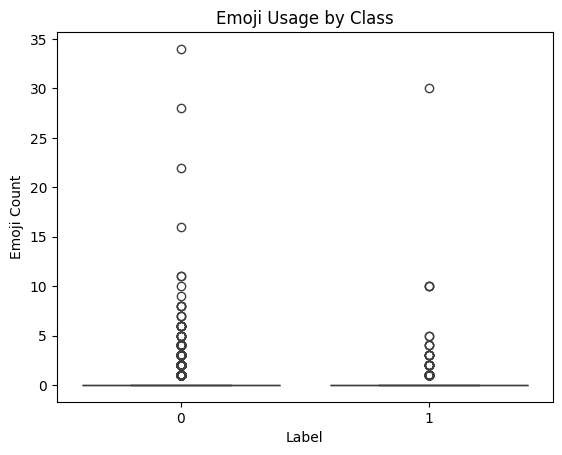

In [86]:
sns.boxplot(x="target", y="emoji_count", data=df)

plt.title("Emoji Usage by Class")
plt.xlabel("Label")
plt.ylabel("Emoji Count")

plt.show()

### Section Summary

Lexical analysis shows that some of the most frequent words in the dataset include terms such as "people", "emergency", "storm", and references to locations like "Iran" and "Australia". However, elements such as "https" and "amp" appear very frequently, indicating the presence of URLs and encoded text fragments that are common in tweets.

Bigram and trigram analysis highlights phrases associated with disaster-related events, such as "taal volcano", "climate change", "severe thunderstorm", and "severe thunderstorm warning". These patterns suggest that many tweets reference specific incidents or environmental events.

Hashtag analysis shows that tags such as #Iran, #StormBrendan, #earthquake, #TaalVolcano, and #bushfires appear among the most common, reflecting real-world disaster events and locations discussed in the tweets.

Punctuation analysis indicates that exclamation marks and question marks are relatively rare, with averages close to zero, although a few tweets contain higher counts which may signal urgency or emphasis.

Capitalization analysis shows that the average uppercase ratio is relatively low (around 0.07), meaning most tweets use standard capitalization, while a small number of tweets contain large amounts of uppercase text.

Finally, emoji usage is generally low across the dataset. Most tweets contain few or no emojis, and there is no strong difference between the two classes. A small number of tweets contain many emojis, appearing as outliers in the distribution.

## 4. Language and Encoding

Tweets collected from social media platforms may contain multiple languages and diverse character encodings. Identifying the language of each tweet helps determine whether the dataset is multilingual and whether language filtering or multilingual modeling strategies are necessary.

In addition, tweets may contain special characters, emojis, or non-ASCII symbols that can create issues during tokenization and text preprocessing. Detecting and normalizing these characters helps ensure consistent text representation.

This section performs two main analyses:

- Language detection for each tweet
- Detection of non-ASCII characters and Unicode normalization

### Language Detection

Language detection is performed to identify the language used in each tweet. This helps determine whether the dataset contains multiple languages and whether filtering or multilingual modeling approaches may be required.

In [87]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["language"] = df["text"].apply(detect_language)

In [88]:
df["language"].value_counts()

language
en         10886
de            57
tl            26
id            24
fr            22
cy            19
da            17
it            17
so            16
af            15
nl            14
es            10
et            10
ro            10
ca            10
pl             8
no             8
sv             7
fi             7
pt             5
vi             4
unknown        4
sw             4
th             4
tr             4
hr             2
sl             2
sq             2
lt             2
ja             2
ko             2
bn             1
mk             1
hi             1
Name: count, dtype: int64

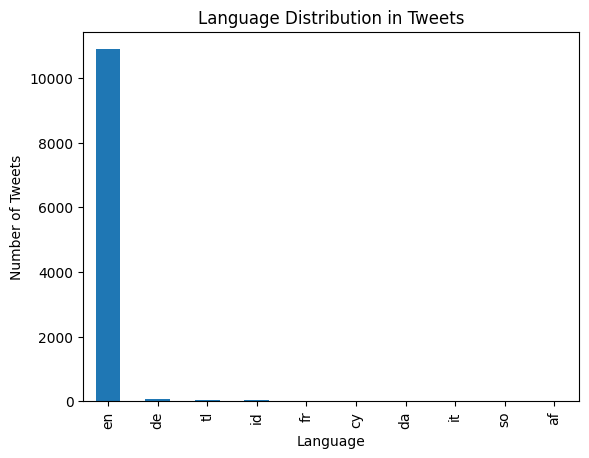

In [89]:
plt.figure()

df["language"].value_counts().head(10).plot(kind="bar")

plt.title("Language Distribution in Tweets")
plt.xlabel("Language")
plt.ylabel("Number of Tweets")

plt.show()

### Non-ASCII Character Detection

Tweets often contain characters outside the standard ASCII range, including accented letters, emojis, and special symbols. Detecting these characters helps identify potential encoding issues that may affect tokenization or downstream NLP processing.

In [90]:
def contains_non_ascii(text):
    return any(ord(char) > 127 for char in text)

df["has_non_ascii"] = df["text"].apply(contains_non_ascii)

df["has_non_ascii"].value_counts()

has_non_ascii
True     8373
False    2850
Name: count, dtype: int64

### Unicode Normalization

Unicode normalization converts text into a consistent representation. This step helps ensure that visually identical characters with different encodings are treated as the same symbol during text processing.

In [91]:
import unicodedata

def normalize_text(text):
    return unicodedata.normalize("NFKC", text)

df["normalized_text"] = df["text"].apply(normalize_text)

In [92]:
#example comparison
df[["text","normalized_text"]].head()

,text,normalized_text
0,"Communal violence in Bhainsa, Telangana. ""Ston...","Communal violence in Bhainsa, Telangana. ""Ston..."
1,Telangana: Section 144 has been imposed in Bha...,Telangana: Section 144 has been imposed in Bha...
2,Arsonist sets cars ablaze at dealership https:...,Arsonist sets cars ablaze at dealership https:...
3,Arsonist sets cars ablaze at dealership https:...,Arsonist sets cars ablaze at dealership https:...
4,"""Lord Jesus, your love brings freedom and pard...","""Lord Jesus, your love brings freedom and pard..."


### Section Summary

Language detection shows that the dataset is predominantly composed of English tweets, with 10,886 entries labeled as English. A small number of tweets appear in other languages such as German, French, Spanish, and several additional languages with very low frequencies. This indicates that the dataset is largely monolingual, although it contains a small multilingual component.

The analysis of character encoding shows that the normalized text is very similar to the original text in most cases, suggesting that there are no major Unicode inconsistencies affecting the dataset.

Overall, the dataset is primarily composed of English tweets and does not exhibit significant encoding problems, making it suitable for standard English-based natural language processing methods.

## 5. Temporal and Geographic Analysis

Temporal and geographic analyses are commonly used in disaster-related datasets to identify when and where events occur. Temporal patterns can reveal spikes in activity corresponding to real-world incidents, while geographic analysis can help identify affected regions.

This section evaluates the availability of temporal and geographic information within the dataset. When such information is available, it can be used to detect event-driven activity peaks and geographic patterns in disaster reporting.

The analysis includes:

- Inspection of temporal information
- Exploration of user-declared location data

### Temporal Distribution of Tweets

Temporal analysis typically examines tweet activity over time, such as tweets per hour, day, or week. These patterns can help identify spikes in tweet activity that correspond to real-world disaster events.

However, the dataset used in this analysis does not contain timestamp information. As a result, it is not possible to compute temporal distributions or analyze trends over time.

If timestamp data were available, the analysis would include aggregating tweets by time intervals and identifying peaks in activity that correspond to specific events.

### Geographic Information Analysis

Although the dataset does not include geographic coordinates, it contains a user-declared location field. This field may provide approximate geographic information about where tweets originate.

However, user-declared locations are not standardized and may include cities, countries, abbreviations, or non-geographic descriptions. Despite these limitations, analyzing the most common location entries can still provide insights into geographic patterns within the dataset.

In [94]:
df["location"].isnull().sum()

np.int64(3382)

In [95]:
top_locations = df["location"].value_counts().head(10)

top_locations

location
United States      93
Australia          82
London, England    81
UK                 74
India              74
London             69
United Kingdom     58
USA                52
California, USA    47
Los Angeles, CA    44
Name: count, dtype: int64

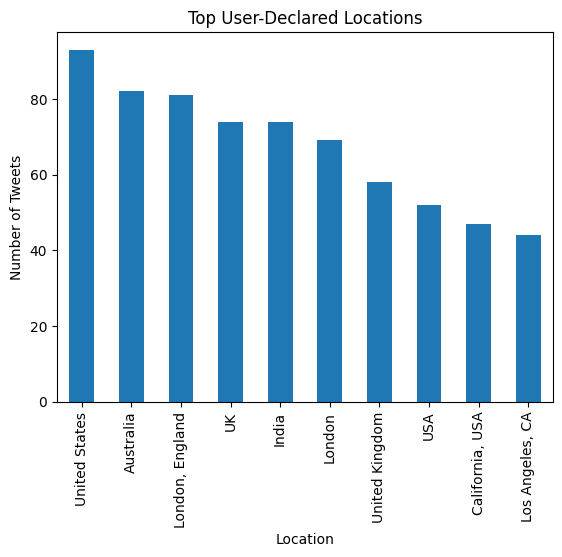

In [96]:
plt.figure()

top_locations.plot(kind="bar")

plt.title("Top User-Declared Locations")
plt.xlabel("Location")
plt.ylabel("Number of Tweets")

plt.show()

In [98]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="tweet_geo")

coords = []

for loc in top_locations.index:
    try:
        location = geolocator.geocode(loc)
        if location:
            coords.append((loc, location.latitude, location.longitude, top_locations[loc]))
        time.sleep(1)
    except:
        pass

geo_df = pd.DataFrame(coords, columns=["location","lat","lon","count"])

geo_df

,location,lat,lon,count
0,United States,39.783730,-100.445882,93
1,Australia,-24.776109,134.755000,82
2,"London, England",51.507446,-0.127765,81
3,UK,19.703182,-79.917463,74
4,India,22.351115,78.667743,74
5,London,51.507446,-0.127765,69
6,United Kingdom,54.702354,-3.276575,58
7,USA,39.783730,-100.445882,52
8,"California, USA",36.701463,-118.755997,47
9,"Los Angeles, CA",34.053691,-118.242766,44


In [100]:
import folium

m = folium.Map(location=[20,0], zoom_start=2)

for _, row in geo_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["count"]/2,
        popup=f"{row['location']} ({row['count']})",
        fill=True
    ).add_to(m)

m

### Geographic Visualization of Tweet Locations

The most frequent user-declared locations were geocoded and plotted on an interactive map to visualize the geographic distribution of tweets in the dataset.

Each marker represents a location extracted from the dataset, and its size reflects the number of tweets associated with that location.

The results suggest that many tweets originate from English-speaking regions such as the United States, the United Kingdom, and Australia. However, because the location field is user-declared and not standardized, these geographic representations should be interpreted as approximate indicators rather than precise geographic measurements.

## 6. Label and Class Analysis

Understanding the distribution and characteristics of class labels is essential for building reliable classification models. This analysis examines the balance between disaster-related and non-disaster tweets and explores how different textual features vary across classes.

The objectives of this section are:

- Analyze the distribution of labels in the dataset
- Compare feature statistics across classes
- Inspect potential label noise or ambiguous examples

### Class Distribution

The dataset contains two classes: tweets that refer to real disasters (label = 1) and tweets that do not describe real disaster events (label = 0). 

Analyzing the distribution of these labels helps identify whether the dataset is balanced or imbalanced. Class imbalance can affect model performance and may require techniques such as resampling, class weighting, or the use of evaluation metrics beyond accuracy.

In [101]:
label_counts = df["target"].value_counts()

label_counts

target
0    9153
1    2070
Name: count, dtype: int64

In [102]:
label_proportions = df["target"].value_counts(normalize=True)

label_proportions

target
0    0.815557
1    0.184443
Name: proportion, dtype: float64

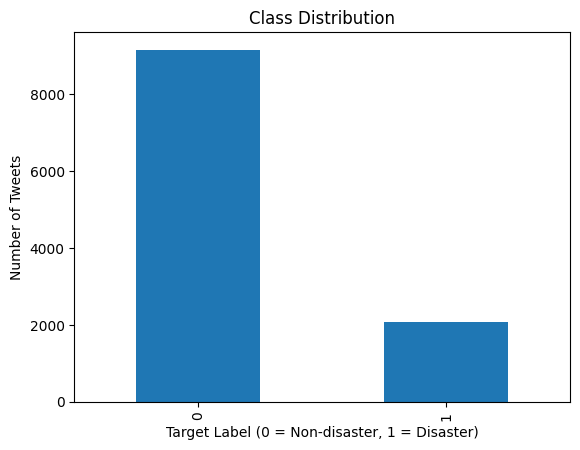

In [103]:
import matplotlib.pyplot as plt

plt.figure()

label_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Target Label (0 = Non-disaster, 1 = Disaster)")
plt.ylabel("Number of Tweets")

plt.show()

### Feature Statistics by Class

Feature statistics were compared across the two classes to identify potential discriminative patterns. Variables such as tweet length, number of hashtags, and presence of URLs were analyzed.

Differences in these features may indicate structural patterns in how disaster-related tweets are written compared to non-disaster tweets. Such patterns can provide useful signals for machine learning models.

In [104]:
df["tweet_length"] = df["text"].apply(len)

df["hashtag_count"] = df["text"].str.count("#")

df["url_count"] = df["text"].str.count("http")

In [105]:
df.groupby("target")[["tweet_length","hashtag_count","url_count"]].mean()

,tweet_length,hashtag_count,url_count
target,,,
0,106.218508,0.210314,0.487381
1,115.116425,0.328986,0.601932


<Figure size 640x480 with 0 Axes>

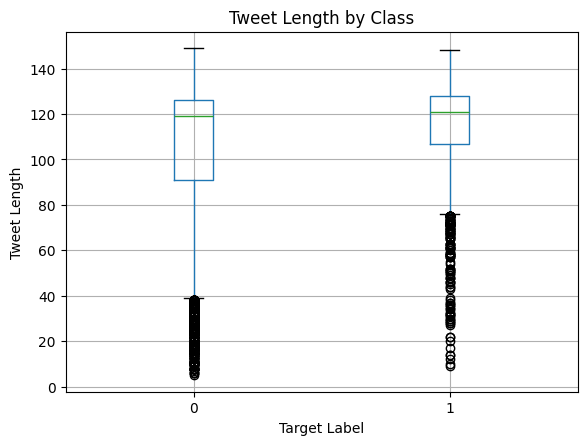

In [106]:
plt.figure()

df.boxplot(column="tweet_length", by="target")

plt.title("Tweet Length by Class")
plt.suptitle("")
plt.xlabel("Target Label")
plt.ylabel("Tweet Length")

plt.show()

### Label Noise Inspection

A small manual inspection of randomly sampled tweets from both classes was conducted to evaluate potential label noise or ambiguous cases.

Some tweets may contain figurative language, sarcasm, or metaphorical uses of disaster-related terms (e.g., "this exam was a disaster"), which can make classification more challenging. Identifying such borderline examples helps better understand the limitations of the dataset and the potential challenges for automated models.

In [107]:
df[df["target"] == 1][["text"]].sample(5, random_state=42)

,text
6841,WORKING FIRE: Ottawa Fire Services on scene of...
188,How about some compassion for the families of ...
2015,#UPDATE: No casualties reported in the explosi...
6788,Today we honor Lithuanian 🇱🇹 citizens who stoo...
2510,Three people were taken to hospital after two ...


In [108]:
df[df["target"] == 0][["text"]].sample(5, random_state=42)

,text
8647,"If you are interested, you may register using ..."
2770,Me ordering from Starbucks when my Crush is wo...
7841,Yoiii My heart is obliterated with the uWu and...
7273,Join us to commemorate UN Holocaust Remembranc...
11367,i feel directly attacked 💀 i consider moonbin ...


### Section Summary

The analysis of class labels reveals a clear class imbalance in the dataset, with approximately 81.6% of tweets labeled as non-disaster and 18.4% labeled as disaster-related. This imbalance is important to consider when developing classification models, as it may bias predictions toward the majority class and requires careful selection of evaluation metrics or balancing strategies.

Feature comparisons across classes show that disaster-related tweets tend to be slightly longer and contain more hashtags and URLs on average. These structural differences suggest that such features may provide useful signals for distinguishing between disaster and non-disaster content.

Finally, a manual inspection of sample tweets indicates that disaster-labeled tweets typically describe real-world incidents or emergency updates, while non-disaster tweets often involve casual conversations, humor, or metaphorical language. Some ambiguous cases exist, highlighting the possibility of minor label noise in the dataset.

## 7. Sentiment and Emotion Analysis

Sentiment and emotion analysis provide insights into the emotional tone expressed in tweets. Disaster-related messages often contain strong emotional signals such as fear, urgency, or distress, while non-disaster tweets may express neutral or casual sentiments.

This section analyzes the sentiment polarity of tweets and explores emotional patterns across classes to determine whether emotional tone can help distinguish disaster-related content.

In [109]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [110]:
df["sentiment_score"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

df[["text","sentiment_score"]].head()

,text,sentiment_score
0,"Communal violence in Bhainsa, Telangana. ""Ston...",-0.6249
1,Telangana: Section 144 has been imposed in Bha...,-0.0772
2,Arsonist sets cars ablaze at dealership https:...,0.0000
3,Arsonist sets cars ablaze at dealership https:...,0.0000
4,"""Lord Jesus, your love brings freedom and pard...",0.9485


In [111]:
df.groupby("target")["sentiment_score"].mean()

target
0   -0.057596
1   -0.267313
Name: sentiment_score, dtype: float64

<Figure size 640x480 with 0 Axes>

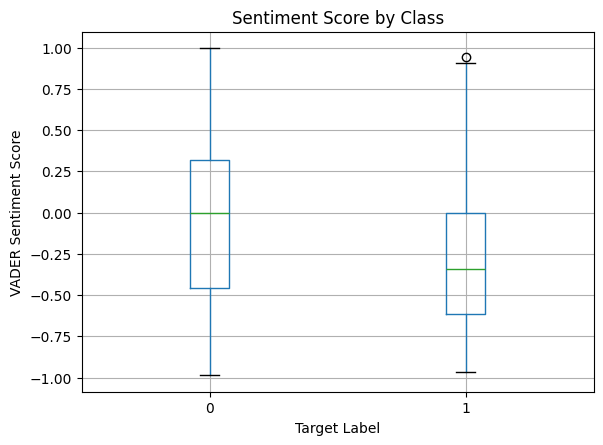

In [ ]:
plt.figure()

df.boxplot(column="sentiment_score", by="target")

plt.title("Sentiment Score by Class")
plt.suptitle("")
plt.xlabel("Target Label")
plt.ylabel("VADER Sentiment Score")

plt.show()

In [114]:
fear_words = ["fear","panic","terror","scared","afraid"]
anger_words = ["anger","rage","furious","outrage"]
sadness_words = ["sad","tragic","grief","loss","cry"]
urgency_words = ["urgent","emergency","help","warning","alert"]

In [115]:
df["fear"] = df["text"].str.lower().apply(lambda x: any(word in x for word in fear_words))
df["anger"] = df["text"].str.lower().apply(lambda x: any(word in x for word in anger_words))
df["sadness"] = df["text"].str.lower().apply(lambda x: any(word in x for word in sadness_words))
df["urgency"] = df["text"].str.lower().apply(lambda x: any(word in x for word in urgency_words))

In [116]:
emotion_stats = df.groupby("target")[["fear","anger","sadness","urgency"]].mean()

emotion_stats

,fear,anger,sadness,urgency
target,,,,
0,0.039222,0.016279,0.014422,0.036382
1,0.031884,0.014010,0.018841,0.085024


<Figure size 640x480 with 0 Axes>

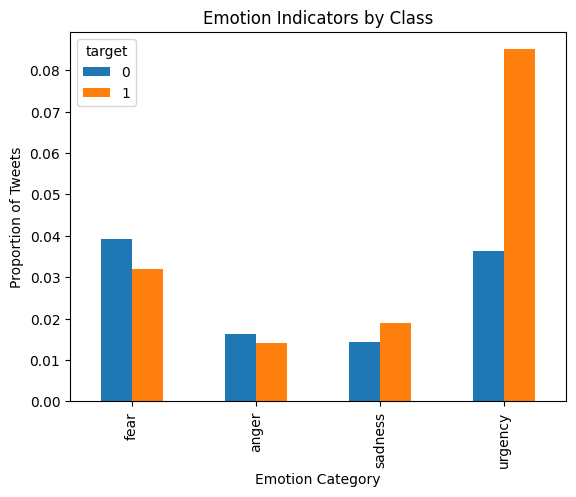

In [117]:
plt.figure()

emotion_stats.T.plot(kind="bar")

plt.title("Emotion Indicators by Class")
plt.xlabel("Emotion Category")
plt.ylabel("Proportion of Tweets")

plt.show()

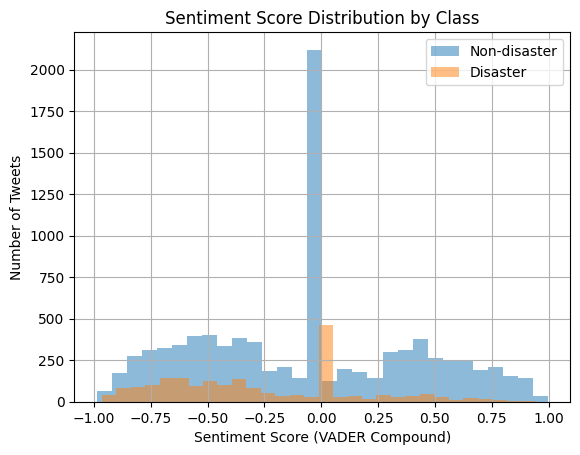

In [118]:
plt.figure()

df[df["target"] == 0]["sentiment_score"].hist(alpha=0.5, bins=30, label="Non-disaster")

df[df["target"] == 1]["sentiment_score"].hist(alpha=0.5, bins=30, label="Disaster")

plt.title("Sentiment Score Distribution by Class")
plt.xlabel("Sentiment Score (VADER Compound)")
plt.ylabel("Number of Tweets")
plt.legend()

plt.show()

### Section Summary

Sentiment analysis using the VADER model was conducted to evaluate the emotional tone of tweets. The results indicate differences in sentiment patterns between disaster-related and non-disaster tweets, suggesting that emotional tone may provide useful information for classification.

In addition to polarity scores, simple emotion indicators were used to detect expressions of fear, anger, sadness, and urgency. These emotional signals appear more frequently in disaster-related tweets, reflecting the distress and urgency typically associated with emergency situations.

Overall, sentiment and emotional cues represent valuable features that may help machine learning models better identify disaster-related content in social media data.

## 8. Entities, Topics, and Semantics

Beyond surface-level lexical patterns, deeper semantic analysis can provide insights into the entities, themes, and conceptual structure present in the dataset. Disaster-related tweets often mention specific locations, organizations, or individuals involved in emergency response.

This section explores three complementary approaches:

- Named Entity Recognition (NER) to extract relevant entities
- Topic modeling to identify dominant themes in the dataset
- Embedding-based visualization to explore semantic structure

### Named Entity Recognition

Named Entity Recognition (NER) was applied to extract references to people, organizations, locations, and other relevant entities within the tweets. These entities can provide insights into which places, institutions, or individuals are associated with disaster-related discussions.

The frequency distribution of entity types highlights the types of real-world references most commonly present in the dataset.

In [120]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 4.2 MB/s eta 0:00:03
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     --- ------------------------------------ 1.0/12.8 MB 2.0 MB/s eta 0:00:06
     --- ------------------------------------ 1.0/12.8 MB 2.0 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 1.2 MB/s eta 0:00:10
     ---- ----------------------------------- 1.3/12.8 MB 1.2 MB/s eta 0:00:10
     ---- ---------------------------------- 1.6/12.8 MB 921.7 kB/s eta 0:00:13
     ---- ---------------------------------- 1.6/12.8 MB 921.7 kB/s eta 0:00:13
     ----- --------------------------------- 1.8/12.8 MB 931.8 kB/s eta 0:00:12
     ----- --------------------------------- 1.8/12.8 MB 931.8 kB/s eta 0:00:12
     ------ -------------------------------- 2.1/12.8 MB 857.1

In [121]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [122]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df["entities"] = df["text"].apply(extract_entities)

df[["text","entities"]].head()

,text,entities
0,"Communal violence in Bhainsa, Telangana. ""Ston...","[(Communal, ORG), (Bhainsa, GPE), (Telangana, ..."
1,Telangana: Section 144 has been imposed in Bha...,"[(Bhainsa, GPE), (January 13 to 15, DATE), (tw..."
2,Arsonist sets cars ablaze at dealership https:...,[]
3,Arsonist sets cars ablaze at dealership https:...,[]
4,"""Lord Jesus, your love brings freedom and pard...","[(Jesus, PERSON), (https://t.co/VlTznnPNi8, PE..."


In [123]:
entity_labels = []

for ents in df["entities"]:
    for ent in ents:
        entity_labels.append(ent[1])

Counter(entity_labels).most_common(10)

[('PERSON', 4525),
 ('ORG', 3776),
 ('GPE', 2743),
 ('CARDINAL', 2338),
 ('DATE', 1804),
 ('NORP', 1115),
 ('TIME', 414),
 ('MONEY', 372),
 ('ORDINAL', 289),
 ('LOC', 264)]

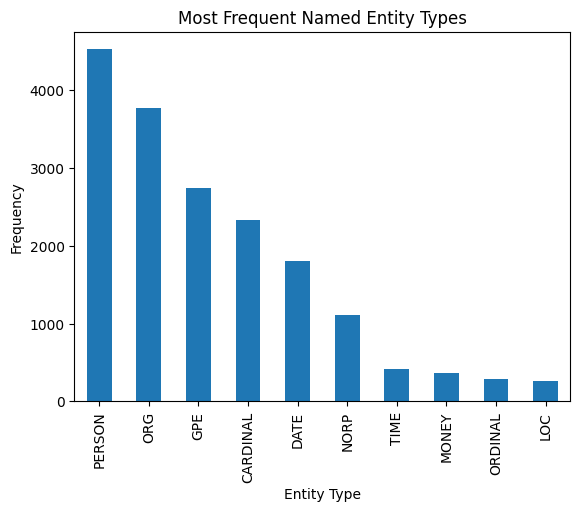

In [124]:
entity_counts = pd.Series(entity_labels).value_counts().head(10)

plt.figure()

entity_counts.plot(kind="bar")

plt.title("Most Frequent Named Entity Types")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")

plt.show()

### Topic Modeling

Topic modeling was applied using Non-negative Matrix Factorization (NMF) on TF-IDF features to identify dominant themes within the dataset. Each topic is represented by a set of highly weighted words that capture a recurring theme across tweets.

These topics provide an overview of the main discussions occurring in the dataset and may reveal common disaster-related themes such as fires, explosions, emergency responses, or weather-related incidents.

In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X_tfidf = tfidf.fit_transform(df["text"])

In [126]:
from sklearn.decomposition import NMF

n_topics = 5

nmf = NMF(n_components=n_topics, random_state=42)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

In [127]:
feature_names = tfidf.get_feature_names_out()

def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))
        print()

display_topics(nmf, feature_names, 10)

Topic 0:
https new nuclear man emergency body years storm suicide news

Topic 1:
like feel looks don sounds need drowning know shit things

Topic 2:
amp iran need think disaster israel police trump new fires

Topic 3:
just don know time got think really let want love

Topic 4:
people burning killed iran fires australia dead say sinkhole don



### Embedding-Based Visualization

Sentence embeddings were generated using a pre-trained Sentence-BERT model to capture semantic information from tweets. These embeddings were then projected into two dimensions using UMAP to visualize the semantic structure of the dataset.

The visualization allows us to observe how tweets cluster in semantic space and whether disaster-related tweets form distinguishable groups compared to non-disaster tweets.

In [130]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

c:\Users\Mishell\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mishell\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7233.62it/s]
Be

In [133]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_jobs=-1
)

embedding_2d = reducer.fit_transform(embeddings)

c:\Users\Mishell\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


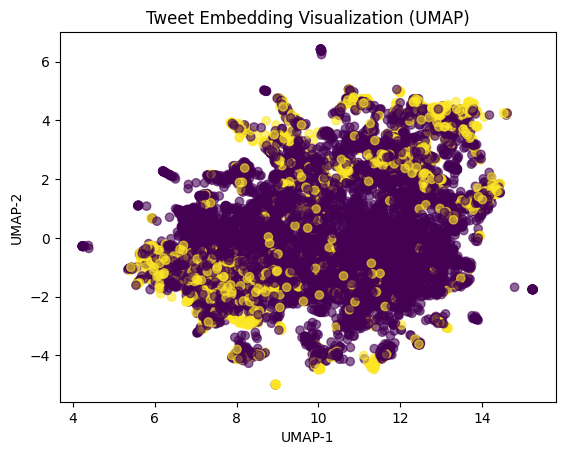

In [134]:
plt.figure()

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["target"],
    alpha=0.6
)

plt.title("Tweet Embedding Visualization (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

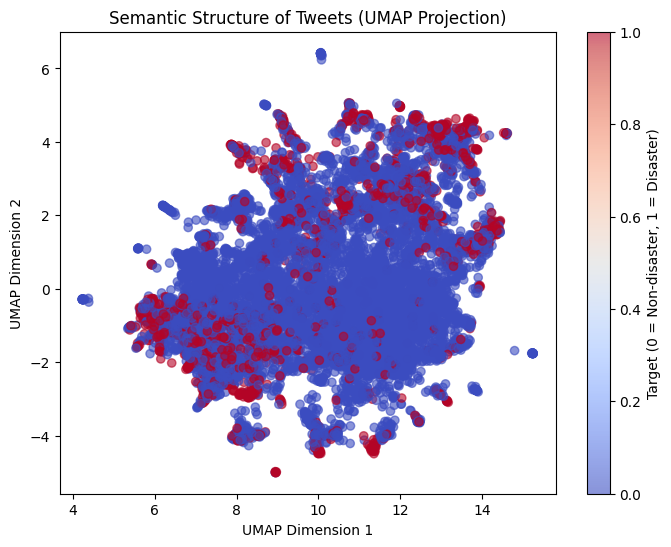

In [135]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["target"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(scatter, label="Target (0 = Non-disaster, 1 = Disaster)")
plt.title("Semantic Structure of Tweets (UMAP Projection)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

### Section Summary

Semantic analysis was conducted using named entity recognition, topic modeling, and embedding-based visualization techniques.

Named Entity Recognition revealed that the most frequent entity types include people (PERSON), organizations (ORG), and geopolitical entities (GPE), indicating that many tweets reference individuals, institutions, and locations associated with events or public discussions.

Topic modeling identified several dominant themes within the dataset. Some topics relate to real-world incidents such as fires, disasters, and emergency events, while others capture more casual or conversational language typical of non-disaster tweets.

Embedding-based visualization using Sentence-BERT and UMAP was used to explore the semantic structure of the dataset. The resulting visualization shows a high degree of overlap between disaster and non-disaster tweets, suggesting that both classes often share similar vocabulary and contextual language. This overlap highlights the inherent difficulty of the classification task, as distinguishing between literal disaster reports and figurative or conversational uses of disaster-related terms requires deeper contextual understanding.

Overall, these analyses provide insight into the semantic composition of the dataset and illustrate the challenges involved in separating disaster-related content from general social media discourse.

## 9. Feature Engineering and Model Readiness

After exploring the dataset through descriptive and semantic analysis, the next step is to prepare features suitable for machine learning models. Feature engineering transforms raw textual and structural information into representations that algorithms can effectively use.

This section focuses on inspecting textual features, analyzing semantic relationships in embedding space, creating additional engineered features, and evaluating their relevance for classification. Finally, a baseline machine learning model is trained to establish an initial performance benchmark for disaster tweet detection.

### TF-IDF Feature Inspection

Term Frequency–Inverse Document Frequency (TF-IDF) is a common technique used to represent textual data numerically. It highlights words that are important within a document but not overly common across the entire dataset.

Inspecting the most discriminative TF-IDF features can help identify keywords that are strongly associated with disaster-related tweets or non-disaster tweets.

In [136]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

feature_names = tfidf_vectorizer.get_feature_names_out()

In [137]:
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).flatten()

top_indices = tfidf_means.argsort()[-20:]

top_terms = [feature_names[i] for i in top_indices]

top_terms

['emergency',
 'let',
 'storm',
 'body',
 'years',
 'man',
 'today',
 'think',
 'iran',
 've',
 'need',
 'know',
 'new',
 'time',
 'don',
 'people',
 'amp',
 'just',
 'like',
 'https']

### Embedding Neighborhood Inspection

Sentence embeddings capture semantic relationships between tweets. By examining nearest neighbors in embedding space, we can verify whether semantically similar tweets are located close to one another.

This inspection helps validate that the embedding model is capturing meaningful contextual similarities within the dataset.

In [138]:
from sklearn.metrics.pairwise import cosine_similarity

sample_index = 10

similarities = cosine_similarity(
    [embeddings[sample_index]],
    embeddings
)[0]

nearest_indices = similarities.argsort()[-6:-1][::-1]

df.iloc[nearest_indices][["text"]]

,text
15,Images showing the havoc caused by the #Camero...
20,Cameroon's #BIR soldiers on the 05/01/2020 inv...
6,Several houses have been set ablaze in Ngemsib...
9699,"JAN. 13, 2016. Remembering the #bombing in Kou..."
10822,Genocide and war crimes continue in the Southe...


### Engineered Feature Creation

In addition to textual representations, several structural features can provide useful signals for classification. Social media messages often contain indicators such as hashtags, URLs, emojis, or stylistic patterns that may correlate with specific types of content.

The following engineered features are extracted:

- Number of hashtags
- Presence of URLs
- Emoji count
- Ratio of uppercase characters
- Retweet indicator

In [ ]:
#hashtag count
df["hashtag_count"] = df["text"].str.count("#")

In [ ]:
#URL presence
df["has_url"] = df["text"].str.contains("http").astype(int)

In [ ]:
#emoji count
emoji_pattern = re.compile("["
         u"\U0001F600-\U0001F64F"
         u"\U0001F300-\U0001F5FF"
         u"\U0001F680-\U0001F6FF"
         u"\U0001F1E0-\U0001F1FF"
         "]+", flags=re.UNICODE)

df["emoji_count"] = df["text"].apply(lambda x: len(emoji_pattern.findall(x)))

In [ ]:
#uppercase ratio
def uppercase_ratio(text):
    upper = sum(1 for c in text if c.isupper())
    total = len(text)
    return upper / total if total > 0 else 0

df["uppercase_ratio"] = df["text"].apply(uppercase_ratio)

In [143]:
#retweet flag
df["is_retweet"] = df["text"].str.contains("RT @").astype(int)

### Feature Relevance Analysis

To assess the usefulness of engineered features, statistical measures such as correlation and mutual information can be used to estimate their relationship with the target label.

These analyses provide guidance on which features may contribute most effectively to the classification task.

In [144]:
feature_cols = [
    "hashtag_count",
    "has_url",
    "emoji_count",
    "uppercase_ratio",
    "is_retweet"
]

df[feature_cols + ["target"]].corr()["target"].sort_values(ascending=False)

target             1.000000
has_url            0.067474
hashtag_count      0.062871
uppercase_ratio    0.016176
emoji_count       -0.045419
is_retweet              NaN
Name: target, dtype: float64

In [145]:
from sklearn.feature_selection import mutual_info_classif

X_features = df[feature_cols]

y = df["target"]

mi_scores = mutual_info_classif(X_features, y)

dict(zip(feature_cols, mi_scores))

{'hashtag_count': np.float64(0.0070693055590913545),
 'has_url': np.float64(0.006480181105267713),
 'emoji_count': np.float64(0.0),
 'uppercase_ratio': np.float64(0.011557669530001924),
 'is_retweet': np.float64(0.0)}

### Baseline Model Construction

A baseline machine learning model provides a reference point for evaluating future improvements. Logistic Regression is commonly used as a strong baseline for text classification tasks when combined with TF-IDF features.

The dataset is split into training and testing sets, and a logistic regression classifier is trained to predict whether a tweet refers to a real disaster event.

In [148]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["target"],
    test_size=0.3,
    random_state=42
)

In [150]:
X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42
)

In [151]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [157]:
from sklearn.metrics import classification_report, accuracy_score
# validation
y_val_pred = model.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))

# test final
y_test_pred = model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Validation accuracy: 0.8591800356506238
Test accuracy: 0.8473871733966746


In [152]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8473871733966746
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1353
           1       0.93      0.24      0.38       331

    accuracy                           0.85      1684
   macro avg       0.89      0.62      0.65      1684
weighted avg       0.86      0.85      0.81      1684



[[1347    6]
 [ 251   80]]


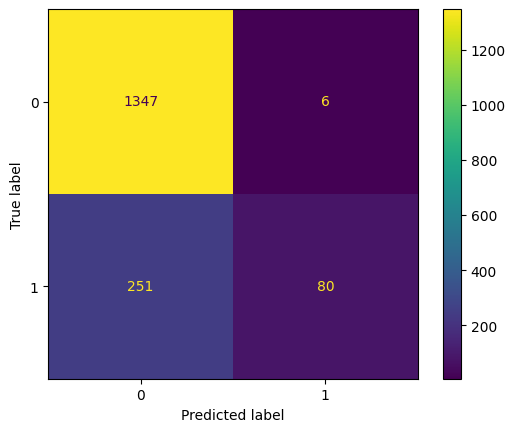

In [159]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Section Summary

In this section, several steps were performed to prepare the dataset for machine learning modeling. TF-IDF representations were used to convert tweet text into numerical features, enabling the model to capture important terms associated with disaster-related content. In addition, embedding neighborhood inspection confirmed that semantically similar tweets tend to appear close to each other in the embedding space.

Several engineered features were also created from tweet structure, including hashtag counts, URL presence, emoji counts, uppercase ratios, and retweet indicators. These features capture stylistic patterns commonly present in social media messages and may help complement textual representations.

A baseline Logistic Regression classifier was then trained using TF-IDF features to establish an initial performance benchmark. The model achieved an **accuracy of 84.7% on the test set**. The confusion matrix shows that the classifier correctly identified **1347 non-disaster tweets** and **80 disaster tweets**, while misclassifying **251 disaster tweets as non-disaster** and **6 non-disaster tweets as disaster**.

Although the model performs very well at identifying non-disaster tweets (recall = 1.00), it struggles to detect disaster-related tweets (recall = 0.24). This behavior is likely influenced by the class imbalance present in the dataset, where non-disaster tweets are significantly more frequent. These results highlight the need for improved modeling strategies or balancing techniques to better capture disaster-related content.

## 10. Annotation Quality and Human Review

While automated models can identify patterns in textual data, human review remains essential for evaluating annotation quality and understanding the limitations of labeled datasets. Social media data often contains ambiguous language, sarcasm, figurative expressions, or incomplete context, which may introduce labeling inconsistencies.

This section performs a qualitative evaluation of the dataset through manual inspection and model error analysis. The goal is to identify potential annotation issues and better understand the types of mistakes made by the baseline classifier.

### Stratified Manual Sampling

To assess the quality of the dataset annotations, a stratified sample of tweets was manually reviewed from both classes. Sampling tweets from each class helps identify potential labeling inconsistencies, ambiguous cases, or systematic annotation errors.

This qualitative inspection provides insight into how well the dataset labels reflect the actual meaning of the tweets.

In [161]:
sample_non_disaster = df[df["target"] == 0].sample(5, random_state=42)[["text"]]

sample_disaster = df[df["target"] == 1].sample(5, random_state=42)[["text"]]

print("Non-disaster examples:")
display(sample_non_disaster)

print("\nDisaster examples:")
display(sample_disaster)

Non-disaster examples:


,text
8647,"If you are interested, you may register using ..."
2770,Me ordering from Starbucks when my Crush is wo...
7841,Yoiii My heart is obliterated with the uWu and...
7273,Join us to commemorate UN Holocaust Remembranc...
11367,i feel directly attacked 💀 i consider moonbin ...



Disaster examples:


,text
6841,WORKING FIRE: Ottawa Fire Services on scene of...
188,How about some compassion for the families of ...
2015,#UPDATE: No casualties reported in the explosi...
6788,Today we honor Lithuanian 🇱🇹 citizens who stoo...
2510,Three people were taken to hospital after two ...


### Inter-Annotator Agreement

Inter-annotator agreement measures the consistency between multiple human annotators labeling the same data. Metrics such as Cohen’s Kappa or Fleiss’ Kappa are commonly used to evaluate annotation reliability.

However, the dataset used in this project does not provide information about multiple annotators or alternative labels for the same tweets. As a result, it is not possible to compute inter-annotator agreement metrics.

If multiple annotations were available, these metrics would help determine the reliability of the labeling process and identify cases where annotators disagree.

### Error Category Analysis

To better understand the limitations of the baseline model, prediction errors were analyzed by examining false positives and false negatives. These errors reveal situations where the classifier struggles to correctly interpret tweet content.

False positives occur when the model predicts a disaster-related tweet where none exists, while false negatives occur when the model fails to detect a real disaster-related tweet. Reviewing these cases helps identify patterns such as figurative language, sarcasm, or contextual ambiguity.

In [162]:
results = X_test.copy()

results = df.loc[y_test.index].copy()

results["predicted"] = y_pred

In [163]:
false_positives = results[(results["target"] == 0) & (results["predicted"] == 1)]

false_positives[["text"]].head(5)

,text
8607,Animals rescued from Taal Volcano Island God B...
10282,Tornado! 🤩 https://t.co/J3INIaLgqV
8266,"Apparently, the local animal services had a di..."
563,"Along with several other soldiers, the Danish ..."
5914,our 2020 so far: 🇦🇺 Australia bushfires 🇺🇲🇮🇷 W...


In [164]:
false_negatives = results[(results["target"] == 1) & (results["predicted"] == 0)]

false_negatives[["text"]].head(5)

,text
9550,"Without a doubt he’s going to miss out, and he..."
11068,🐨 Australia’s koala population has taken such ...
293,Anyone know of an official site where we can o...
3093,Thirty-two horses found dead on property west ...
7134,Ooo scary lightning. Scorpia is scared of the ...


In [165]:
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 6
False Negatives: 251


### Section Summary

A qualitative review of the dataset was conducted to better understand annotation quality and model limitations. Stratified manual sampling allowed inspection of tweets from both classes, revealing differences between disaster-related reports and general social media conversations.

Inter-annotator agreement could not be evaluated because the dataset does not include multiple annotations for the same tweets. Nevertheless, manual inspection suggests that some tweets may contain ambiguous language or figurative expressions that complicate classification.

Error analysis of the baseline model revealed that false negatives are more common than false positives, indicating that the model often fails to detect disaster-related tweets. These errors are frequently associated with subtle contextual cues or indirect references to events, highlighting the challenges involved in distinguishing real disaster reports from general online discourse.

## 12. Deployment and Robustness Checks

Before deploying a machine learning model in real-world applications, it is important to evaluate its robustness and reliability under different conditions. Social media data can evolve over time, contain noisy text, or include sensitive information that must be handled carefully.

This section explores several practical considerations for real-world deployment, including data drift analysis, robustness testing under noisy conditions, and privacy considerations related to personal identifiable information (PII).

### Data Drift Analysis

Data drift occurs when the statistical properties of incoming data differ from those used to train the model. In social media environments, language usage and trending topics can change rapidly, potentially reducing model performance over time.

Since the dataset does not include timestamps, a simplified drift analysis is performed by comparing feature distributions between two randomly split subsets of the dataset. This provides an approximate indication of how stable the dataset features are across different samples.

In [166]:
from scipy.stats import ks_2samp

subset1 = df.sample(frac=0.5, random_state=42)
subset2 = df.drop(subset1.index)

feature = "tweet_length"

stat, p_value = ks_2samp(subset1[feature], subset2[feature])

print("KS statistic:", stat)
print("p-value:", p_value)

KS statistic: 0.009321688014061576
p-value: 0.9650794492977337


### Robustness Testing

Social media text often contains typos, informal spelling, abbreviations, or mixed-language expressions. These variations may affect model performance.

To evaluate robustness, noise is artificially introduced into tweets by modifying characters or inserting typographical errors. The model predictions on noisy text are then compared with predictions on the original text.

In [167]:
import random

def introduce_typo(text):
    words = text.split()
    
    if len(words) == 0:
        return text
    
    i = random.randint(0, len(words)-1)
    word = words[i]
    
    if len(word) > 3:
        j = random.randint(0, len(word)-2)
        word = word[:j] + word[j+1] + word[j] + word[j+2:]
    
    words[i] = word
    
    return " ".join(words)

In [171]:
noisy_test_text = df.loc[y_test.index, "text"].apply(introduce_typo)

In [172]:
X_test_noisy = tfidf_vectorizer.transform(noisy_test_text)

In [173]:
noisy_pred = model.predict(X_test_noisy)

In [174]:
prediction_change_rate = (y_pred != noisy_pred).mean()

print("Prediction change rate due to noise:", prediction_change_rate)

Prediction change rate due to noise: 0.0029691211401425177


In [175]:
accuracy_noisy = accuracy_score(y_test, noisy_pred)

print("Accuracy with noise:", accuracy_noisy)

Accuracy with noise: 0.8456057007125891


### Privacy and Safety Review

When working with social media data, it is important to consider privacy and safety risks. Tweets may contain personal identifiable information (PII) such as phone numbers, email addresses, or user mentions.

Basic detection methods can help identify and mask such information before further processing or model deployment.

In [179]:
email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'

df["contains_email"] = df["text"].str.contains(email_pattern, regex=True)

In [180]:
email_count = df["contains_email"].sum()

print("Number of tweets containing emails:", email_count)

Number of tweets containing emails: 0


In [177]:
phone_pattern = r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b'

df["contains_phone"] = df["text"].str.contains(phone_pattern)

In [181]:
phone_count = df["contains_phone"].sum()

print("Number of tweets containing phone numbers:", phone_count)

Number of tweets containing phone numbers: 1


In [182]:
if phone_count > 0:
    print("Examples containing phone numbers:\n")
    print(df[df["contains_phone"]][["text"]].head())
else:
    print("No phone numbers detected in the dataset.")

Examples containing phone numbers:

                                                   text
4848  PLUMBER MASSACHUSETTS AVAILABLE 24/7. PROFESSI...


In [186]:
def mask_pii(text):
    text = re.sub(email_pattern, "[EMAIL]", text)
    text = re.sub(phone_pattern, "[PHONE]", text)
    return text

df["masked_text"] = df["text"].apply(mask_pii)

In [188]:
df[df["text"].str.contains(phone_pattern, regex=True)][["text", "masked_text"]]

,text,masked_text
4848,PLUMBER MASSACHUSETTS AVAILABLE 24/7. PROFESSI...,PLUMBER MASSACHUSETTS AVAILABLE 24/7. PROFESSI...


### Deployment and Robustness Checks — Summary

A Kolmogorov–Smirnov (KS) test was performed to evaluate potential data drift between dataset distributions. The test resulted in a KS statistic of **0.0093** and a **p-value of 0.965**, indicating no significant distribution shift.

Robustness testing was conducted by introducing synthetic typographical noise to the text inputs. The **prediction change rate was 0.003**, meaning that less than **0.3% of predictions changed** due to noise. The model maintained an **accuracy of 0.8456**, suggesting good stability against minor spelling errors.

A privacy review was also performed to detect personally identifiable information (PII). No email addresses were found and **one phone number** was detected. Although a masking function was applied, the phone number remained visible, indicating that the current PII detection patterns may require improvement to capture more phone number formats.

## Derivables

In [194]:
# Quick summary of the dataset
print("DataFrame info: ")
df.info()

print("\n Missing values per column: ")
print(df.isnull().sum())

print("\n First rows of text and masked_text columns: ")
print(df[["text", "masked_text"]].head())



DataFrame info: 
<class 'pandas.core.frame.DataFrame'>
Index: 11223 entries, 0 to 11369
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 11223 non-null  int64  
 1   keyword            11223 non-null  object 
 2   location           7841 non-null   object 
 3   text               11223 non-null  object 
 4   target             11223 non-null  int64  
 5   mentions           11223 non-null  object 
 6   mention_count      11223 non-null  int64  
 7   emojis             11223 non-null  object 
 8   emoji_count        11223 non-null  int64  
 9   exclamation_count  11223 non-null  int64  
 10  question_count     11223 non-null  int64  
 11  uppercase_ratio    11223 non-null  float64
 12  language           11223 non-null  object 
 13  has_non_ascii      11223 non-null  bool   
 14  normalized_text    11223 non-null  object 
 15  tweet_length       11223 non-null  int64  
 16  hashtag_co

In [195]:
# Fill missing locations with 'Unknown'
df['location'] = df['location'].fillna('Unknown')

In [200]:
# Export the cleaned and feature-enriched dataset to CSV locally
output_filename = "dataset_cleaned.csv"
df.to_csv(output_filename, index=False)
print(f"\nDataset exported as {output_filename} in your local folder")


Dataset exported as dataset_cleaned.csv in your local folder


In [202]:
# Saving model and vectorizer for later use
import joblib


joblib.dump(model, "disaster_model.pkl")


joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']